# Proof-of-Concept 4-Parameter Model

This notebook demonstrates a small proof-of-concept emulator that predicts the **binned kSZ angular power spectrum (Dl)** using 4 reionization params ($z_{mean}$, $\alpha$, $k_b$, $b_0$).

In [8]:
import sys
import os
from pathlib import Path

from src.emulator.data.dataloaders import make_dataloaders

ROOT = Path("..").resolve()
SRC = ROOT / "src/"
sys.path.insert(0, str(SRC))

import h5py
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
plt.rc("figure", figsize=(6, 4), dpi=150)

from emulator.models.poc_four_params import POCEmulatorFourParamsV2
from emulator.data.dataloaders import load_training_arrays
from emulator.training.train_loop import FitConfig, fit
from emulator.data.dataloaders import DataLoaderConfig

## File Paths
The condensed v6 simulation dataset is constructed with: $Y = \ln(D_\ell)$

In [9]:
H5_PATH = Path("../data/processed/condensed_v6.h5").resolve()
MODEL_PATH = Path("../checkpoints/poc_four_params/model.pt").resolve()
NORM_PATH = Path("../checkpoints/poc_four_params/norm/").resolve()

## Define Configs

In [10]:
dlcfg = DataLoaderConfig(
    batch_size=64,
    seed=42,
    shuffle_train=True,
    normalize_X=True,
    normalize_Y=True
)

fitcfg = FitConfig(
    epochs=200,
    device="mps",
    early_stopping_patience=50,
    gradient_clipping=None
)

## Prepare Data and Model

In [11]:
loaders, norms, ell = make_dataloaders(H5_PATH, split={"train": 0.8, "val": 0.2}, config=dlcfg)

model = POCEmulatorFourParamsV2()
lossfn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-6)

model.eval()

POCEmulatorFourParamsV2(
  (fc1): Linear(in_features=4, out_features=20, bias=True)
  (fc2): Linear(in_features=20, out_features=20, bias=True)
  (out): Linear(in_features=20, out_features=5, bias=True)
  (activation): ReLU()
)

## Train Model

In [12]:
history = fit(model, loaders["train"], loaders["val"], optimizer, lossfn, config=fitcfg)

Epoch 001: train=0.979075, val=0.992139
Epoch 002: train=0.903453, val=0.907260
Epoch 003: train=0.813816, val=0.796046
Epoch 004: train=0.698223, val=0.646377
Epoch 005: train=0.554037, val=0.478039
Epoch 006: train=0.406762, val=0.323221
Epoch 007: train=0.276691, val=0.206752
Epoch 008: train=0.181719, val=0.131802
Epoch 009: train=0.124921, val=0.093054
Epoch 010: train=0.097980, val=0.075277
Epoch 011: train=0.084499, val=0.066474
Epoch 012: train=0.074555, val=0.061187
Epoch 013: train=0.066623, val=0.055558
Epoch 014: train=0.061349, val=0.051274
Epoch 015: train=0.056475, val=0.047789
Epoch 016: train=0.052669, val=0.045188
Epoch 017: train=0.049922, val=0.043310
Epoch 018: train=0.047574, val=0.042097
Epoch 019: train=0.045210, val=0.040405
Epoch 020: train=0.043428, val=0.038608
Epoch 021: train=0.041734, val=0.037390
Epoch 022: train=0.040528, val=0.036539
Epoch 023: train=0.039033, val=0.035799
Epoch 024: train=0.038135, val=0.034974
Epoch 025: train=0.037127, val=0.034086


## Save Model and Normalization

In [13]:
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
torch.save(model.state_dict(), MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")

NORM_PATH.parent.mkdir(parents=True, exist_ok=True)
np.save(NORM_PATH / "X_mean.npy", norms["X"].mean)
np.save(NORM_PATH / "X_std.npy", norms["X"].std)
np.save(NORM_PATH / "Y_mean.npy", norms["Y"].mean)
np.save(NORM_PATH / "Y_std.npy", norms["Y"].std)
np.save(NORM_PATH / "ell", np.asarray(ell))

Model saved to /Users/robertxpearce/Desktop/reionization-emulator/checkpoints/poc_four_params/model.pt


# Load Model and Normalization

In [14]:
device = torch.device("mps")

X_mean = np.load(f"{NORM_PATH}/X_mean.npy")
X_std  = np.load(f"{NORM_PATH}/X_std.npy")
Y_mean = np.load(f"{NORM_PATH}/Y_mean.npy")
Y_std  = np.load(f"{NORM_PATH}/Y_std.npy")
ell    = np.load(f"{NORM_PATH}/ell.npy")

model = POCEmulatorFourParamsV2().to(device)
state_dict = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state_dict)

<All keys matched successfully>

## Define Predict Function

In [15]:
def predict(params, model, X_mean, X_std, Y_mean, Y_std):
    params = (params - X_mean) / X_std

    xb = torch.from_numpy(params).to(device)

    model.eval()
    with torch.no_grad():
        pred_norm = model(xb).cpu().numpy()

    pred_log = pred_norm * Y_std + Y_mean
    pred_dl = np.exp(pred_log)

    return pred_dl

## Error Metrics

In [16]:
X, Y, ell = load_training_arrays(H5_PATH)

pred = []
true = []

pred = predict(X, model, X_mean, X_std, Y_mean, Y_std)
true = np.exp(Y)

errors = np.abs((pred - true) / true)

mse = np.mean((pred - true)**2)
mae = np.mean(np.abs((pred - true)))
percent_err = np.mean(errors) * 100

bin_percent_err = np.mean(errors, axis=0) * 100

flat_idx = np.argmax(errors)
i, b = np.unravel_index(flat_idx, errors.shape)

print("Mean Squared Error (MSE):\t", mse)
print("Mean Absolute Error (MAE):\t", mae)
print("Mean % Error:\t\t\t\t", percent_err)
print()
print("Max % Error:\t\t\t\t", np.max(errors) * 100)
print("Mean % Error Per ell Bin:\t", bin_percent_err)
print()
print("Worst Case Sim:\t", i)
print("Worst Case Bin:\t", b)
print("True Dl:\t\t", true[i, b])
print("Pred Dl:\t\t", pred[i, b])
print("% error:\t\t", errors[i, b] * 100)

Mean Squared Error (MSE):	 0.0034316678
Mean Absolute Error (MAE):	 0.040974036
Mean % Error:				 4.4116373

Max % Error:				 27.501446
Mean % Error Per ell Bin:	 [5.2805033 4.3177223 4.161631  4.0875854 4.210755 ]

Worst Case Sim:	 210
Worst Case Bin:	 0
True Dl:		 1.255212
Pred Dl:		 0.9100105
% error:		 27.501446


## Isolate Sim

In [17]:
sim_idx = 210

X, Y, ell = load_training_arrays(H5_PATH)
params = X[sim_idx]
true_dl = np.exp(Y[sim_idx])
pred_dl = predict(params, model, X_mean, X_std, Y_mean, Y_std)

print(f"Params:\t\t {params}")
print()
print(f"True:\t\t {true_dl}")
print(f"Predicted:\t {pred_dl}")

Params:		 [7.047597   0.7855842  1.6908534  0.31995168]

True:		 [1.255212   0.9633558  0.67719126 0.54858387 0.53951526]
Predicted:	 [0.9100105  0.77668    0.5762029  0.4605078  0.46799314]


## True vs Predicted $D_\ell$

In [18]:
def plot_sim(sim_idx):
    X, Y, ell = load_training_arrays(H5_PATH)

    params = X[sim_idx]
    true_dl = np.exp(Y[sim_idx])
    pred_dl = predict(params, model, X_mean, X_std, Y_mean, Y_std)

    pct_err = 100.0 * (pred_dl - true_dl) / true_dl
    
    print(f"Sim Index:\t\t{sim_idx}")
    print(f"Params:\t\t\t{params}")
    print(f"True Dl:\t\t{true_dl}")
    print(f"Predicted Dl:\t{pred_dl}")
    print(f"% Error:\t\t{pct_err}")

    plt.plot(ell, true_dl, marker="o", label=r"True $D_\ell$")
    plt.plot(ell, pred_dl, marker="s", label=r"Predicted $D_\ell$")
    plt.xlabel(r"$\ell$ bin center")
    plt.ylabel(r"$D_\ell$")
    plt.title(f"True vs Predicted $D_\\ell$ (sim {sim_idx})")
    plt.legend()
    plt.grid(True)
    plt.show()

Sim Index:		0
Params:			[7.3246355  0.48715696 0.25348133 0.71027094]
True Dl:		[1.4497963  1.1481824  0.8139568  0.66767186 0.66289914]
Predicted Dl:	[1.435549   1.1343312  0.8031054  0.65225005 0.6506278 ]
% Error:		[-0.98271036 -1.2063559  -1.3331646  -2.3097885  -1.8511631 ]


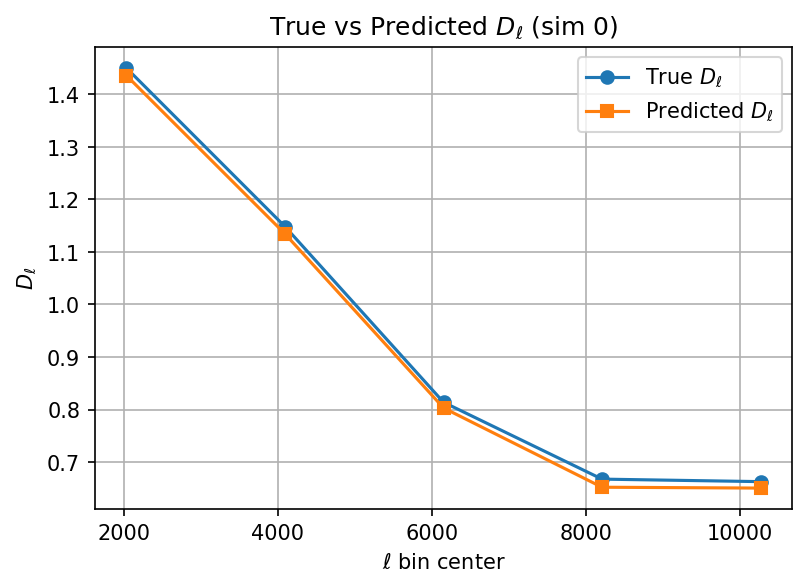

Sim Index:		210
Params:			[7.047597   0.7855842  1.6908534  0.31995168]
True Dl:		[1.255212   0.9633558  0.67719126 0.54858387 0.53951526]
Predicted Dl:	[0.9100105  0.77668    0.5762029  0.4605078  0.46799314]
% Error:		[-27.501444 -19.377659 -14.912823 -16.055168 -13.256737]


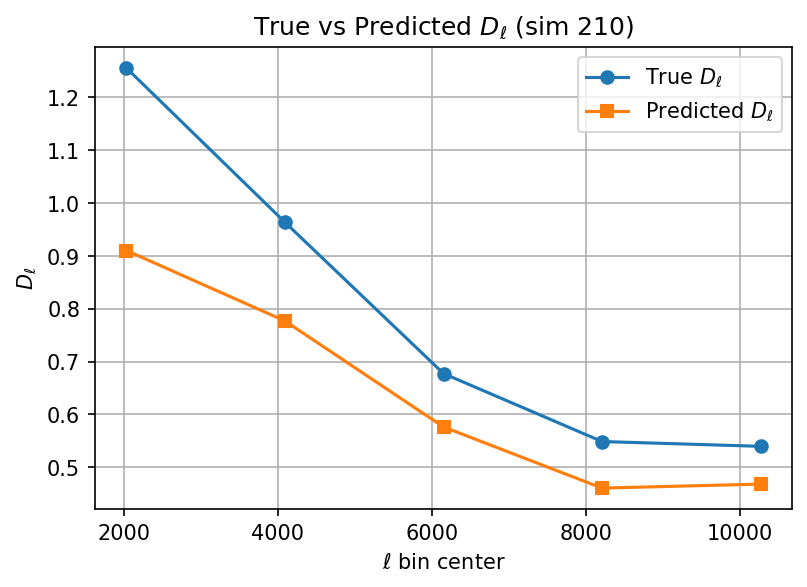

In [19]:
plot_sim(0)
plot_sim(210)